In [ ]:

!pip install lightgbm
import lightgbm
!pip install keras-tuner

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from keras_tuner.tuners import BayesianOptimization
from sklearn.metrics import mean_squared_error,accuracy_score,r2_score,mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/dataset.csv')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1823710 entries, 0 to 1823709
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Unnamed: 0              int64  
 1   product_id              int64  
 2   order_dow               int64  
 3   order_hour_of_day       int64  
 4   days_since_prior_order  float64
 5   product_name            object 
 6   aisle_id                int64  
 7   department_id           int64  
 8   order_count             int64  
 9   order_frequency         int64  
 10  reorder_prob            float64
 11  demand                  int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 167.0+ MB


In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
df.head()

,product_id,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,order_count,order_frequency,reorder_prob,demand
0,4210,0,18,30.0,Whole Milk,84,16,1147,34,0.813426,1
1,11210,0,18,30.0,Extra Large Grade A Eggs,86,16,15,34,0.666667,1
2,2839,0,18,30.0,Original Slices Pepperoni,96,20,40,34,0.375000,1
3,19836,0,18,30.0,Original Breakfast Sausage Links,106,12,107,34,0.551402,1
4,49505,0,18,30.0,Hot Italian Sausage,106,12,52,34,0.596154,1


In [ ]:
df.isna().sum()

,0
product_id,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0
product_name,0
aisle_id,0
department_id,0
order_count,0
order_frequency,0
reorder_prob,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1823710 entries, 0 to 1823709
Data columns (total 11 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   product_id              int64  
 1   order_dow               int64  
 2   order_hour_of_day       int64  
 3   days_since_prior_order  float64
 4   product_name            object 
 5   aisle_id                int64  
 6   department_id           int64  
 7   order_count             int64  
 8   order_frequency         int64  
 9   reorder_prob            float64
 10  demand                  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 153.1+ MB


In [ ]:
vectorizer= TfidfVectorizer(max_features=100)
tfidf_matrix=vectorizer.fit_transform(df['product_name'].fillna("")).toarray()
tfidf_df=pd.DataFrame(tfidf_matrix,columns= [f'tfidf_matrix{i}' for i in range(tfidf_matrix.shape[1])])

In [ ]:
df=df.drop(columns=['product_name'])


In [ ]:
df=pd.concat([df,tfidf_df],axis=1)

In [ ]:
X = df.drop(columns=['demand'])
y = df['demand']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print(f' X_train shape:{X_train.shape}\n X_test shape:{X_test.shape}\n y_train shape:{y_train.shape}\n y_test shape:{y_test.shape}')


 X_train shape:(1276597, 109)
 X_test shape:(547113, 109)
 y_train shape:(1276597,)
 y_test shape:(547113,)


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
print(f' X_val shape:{X_val.shape}\n X_test shape:{X_test.shape}\n y_val shape:{y_val.shape}\n y_test shape:{y_test.shape}')

 X_val shape:(273556, 109)
 X_test shape:(273557, 109)
 y_val shape:(273556,)
 y_test shape:(273557,)


In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

1. LGBM model

In [ ]:
param={ 'num_leaves': np.arange(10, 100, 10),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500]}

In [ ]:
lgb_model=lgb.LGBMRegressor()
lgb_search=RandomizedSearchCV(lgb_model,param,n_iter=10,cv=3,n_jobs=-1,verbose=3)

In [ ]:
with tqdm(total=lgb_search.n_iter, desc="LightGBM RandomizedSearchCV") as pbar:
        def update(params):
            pbar.update()
            return params

        lgb_search = lgb_search.fit(X_train, y_train)

LightGBM RandomizedSearchCV:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.245413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11003
[LightGBM] [Info] Number of data points in the train set: 1276597, number of used features: 109
[LightGBM] [Info] Start training from score 1.799158


LightGBM RandomizedSearchCV:   0%|          | 0/10 [04:29<?, ?it/s]


In [ ]:
lgb_pred=lgb_search.best_estimator_.predict(X_test)

In [ ]:
print(f'lgb mean square error: {mean_squared_error(y_test,lgb_pred)}')

lgb mean square error: 1.7229460661213176


In [ ]:
import joblib
joblib.dump(lgb_search.best_estimator_, 'lgb_model.pkl')

['lgb_model.pkl']

#2. MLP

In [ ]:
import traceback

def build_mlp(hp):
    try:
        model = Sequential()
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
        model.add(Dense(hp.Int('units', 32, 96, step=16), activation='relu'))
        model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    except Exception as e:
        print(f"Error in build_mlp: {e}")
        traceback.print_exc()  # Print the full traceback
        raise  # Re-raise the exception to stop the trial

In [ ]:
tuner = BayesianOptimization(build_mlp, objective='val_loss', max_trials=10, executions_per_trial=1)
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val), verbose=1,batch_size=len(X_train)//32)
mlp_model = tuner.get_best_models(num_models=1)[0]
mlp_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=1,batch_size=128)

Reloading Tuner from ./untitled_project/tuner0.json
Epoch 1/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 3.1055 - mae: 0.8665 - val_loss: 3.0115 - val_mae: 0.8493
Epoch 2/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 2.9367 - mae: 0.8462 - val_loss: 2.8681 - val_mae: 0.8583
Epoch 3/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 55s 5ms/step - loss: 2.8053 - mae: 0.8360 - val_loss: 2.8365 - val_mae: 0.8421
Epoch 4/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 2.7412 - mae: 0.8358 - val_loss: 2.7756 - val_mae: 0.8264
Epoch 5/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 2.6914 - mae: 0.8327 - val_loss: 2.7852 - val_mae: 0.8260
Epoch 6/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 2.6657 - mae: 0.8290 - val_loss: 2.7373 - val_mae: 0.8321
Epoch 7/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 2.6083 - mae: 0.8241 - val_loss: 2.6800 - val_mae: 0.8360
Epoch 8/50
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 2.5855 - mae: 0.8236 - val_loss: 2.665

In [ ]:
mlp_model.fit(X_train, y_train, epochs=70, initial_epoch=50, validation_data=(X_val, y_val), verbose=1, batch_size=128)

Epoch 51/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 2.2358 - mae: 0.7893 - val_loss: 2.3680 - val_mae: 0.8150
Epoch 52/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 2.2242 - mae: 0.7879 - val_loss: 2.3760 - val_mae: 0.7866
Epoch 53/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 2.2328 - mae: 0.7880 - val_loss: 2.3603 - val_mae: 0.8095
Epoch 54/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 2.2231 - mae: 0.7868 - val_loss: 2.3807 - val_mae: 0.8009
Epoch 55/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 2.2049 - mae: 0.7869 - val_loss: 2.3695 - val_mae: 0.8367
Epoch 56/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 2.2253 - mae: 0.7883 - val_loss: 2.3376 - val_mae: 0.7873
Epoch 57/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 2.2217 - mae: 0.7859 - val_loss: 2.3689 - val_mae: 0.8094
Epoch 58/70
9974/9974 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 2.2122 - mae: 0.7856 - val_loss: 2.3430 - val_mae: 0.7762
Epoch 59/70
9974/9974 ━━

In [ ]:
mlp_model.save("new_mlp_model.keras")

In [ ]:
mlp_model.save("mlp_model.weights.keras")

In [ ]:
mlp_pred=mlp_model.predict(X_test)
print(f'mlp mean square error: {mean_squared_error(y_test,mlp_pred)}')

8549/8549 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
mlp mean square error: 2.2909255027770996


#3. CATBOOST

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.7 MB/s eta 0:00:00


In [ ]:
import catboost
from catboost import CatBoostRegressor

In [ ]:
# Define the parameter grid
param_grid = {
    'iterations': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
}

# Create the CatBoost model
catboost_model = CatBoostRegressor(loss_function='RMSE', verbose=0)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    catboost_model, param_distributions=param_grid, n_iter=10, cv=3,
    scoring='neg_mean_squared_error', random_state=42
)



In [ ]:
# Fit the model
random_search.fit(X_train, y_train)

# Get the best model and its score


In [ ]:
best_model = random_search.best_estimator_
best_score = random_search.best_score_

print(f"Best model: {best_model}")
print(f"Best score (negative MSE): {best_score}")

# Evaluate the best model on the test set
catboost_pred = best_model.predict(X_test)
print(f'CatBoost MSE after tuning: {mean_squared_error(y_test, catboost_pred)}')

0:	learn: 2.1327841	test: 2.1714089	best: 2.1714089 (0)	total: 296ms	remaining: 3m 12s
1:	learn: 2.0704271	test: 2.1084891	best: 2.1084891 (1)	total: 576ms	remaining: 3m 6s
2:	learn: 2.0171565	test: 2.0554823	best: 2.0554823 (2)	total: 984ms	remaining: 3m 32s
3:	learn: 1.9729790	test: 2.0107318	best: 2.0107318 (3)	total: 1.44s	remaining: 3m 53s
4:	learn: 1.9343474	test: 1.9722848	best: 1.9722848 (4)	total: 1.94s	remaining: 4m 10s
5:	learn: 1.9014546	test: 1.9389549	best: 1.9389549 (5)	total: 2.39s	remaining: 4m 16s
6:	learn: 1.8746639	test: 1.9119568	best: 1.9119568 (6)	total: 2.89s	remaining: 4m 25s
7:	learn: 1.8508112	test: 1.8879112	best: 1.8879112 (7)	total: 3.45s	remaining: 4m 37s
8:	learn: 1.8315517	test: 1.8683060	best: 1.8683060 (8)	total: 3.93s	remaining: 4m 39s
9:	learn: 1.8149537	test: 1.8512942	best: 1.8512942 (9)	total: 4.22s	remaining: 4m 30s
10:	learn: 1.8013150	test: 1.8375737	best: 1.8375737 (10)	total: 4.49s	remaining: 4m 20s
11:	learn: 1.7890547	test: 1.8251371	best:

In [ ]:
catboost_pred=catboost_model.predict(X_test)
print(f'catboost mean square error: {mean_squared_error(y_test,catboost_pred)}')

catboost mean square error: 2.3644746743371465


In [ ]:
joblib.dump(catboost_model, 'catboost_model.pkl')

['catboost_model.pkl']

In [ ]:
import joblib
lgb_model = joblib.load('/content/drive/MyDrive/lgb_model.pkl')


In [ ]:
mlp_model=keras.models.load_model('/content/drive/MyDrive/new_mlp_model.keras')

In [ ]:
catboost_model= joblib.load('/content/catboost_model.pkl')

In [ ]:
y_pred_lgb= lgb_model.predict(X_test)
y_pred_mlp=mlp_model.predict(X_test)
y_pred_cat=catboost_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


8549/8549 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


#Hybrid Model(LGM+MLP+CATBOOST)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
stacked_model=np.column_stack((y_pred_lgb,y_pred_mlp,y_pred_cat))

In [ ]:
meta_model=Ridge()

In [ ]:
meta_model.fit(stacked_model,y_test)

Ridge()

In [ ]:
hybrid_pred=meta_model.predict(stacked_model)

#Evaluation

In [ ]:
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mse_catboost=mean_squared_error(y_test,y_pred_cat)

In [ ]:
print("LGB MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("MLP MAE:", mean_absolute_error(y_test, y_pred_mlp))
print("CAT MAE:", mean_absolute_error(y_test, y_pred_cat))
print("Hybrid Model MAE:", mean_absolute_error(y_test, hybrid_pred))
print("LGB MSE:", mse_lgb)
print("MLP MSE:", mse_mlp)
print("CAT MSE:", mse_catboost)
print("Hybrid Model MSE:", mean_squared_error(y_test, hybrid_pred))
print("LGB R2 Score:", r2_score(y_test, y_pred_lgb))
print("MLP R2 Score:", r2_score(y_test, y_pred_mlp))
print("CAT R2 Score:", r2_score(y_test, y_pred_cat))
print("Hybrid Model R2 Score:", r2_score(y_test, hybrid_pred))

LGB MAE: 0.7030561021276649
MLP MAE: 0.7898784279823303
CAT MAE: 0.7781005877382374
Hybrid Model MAE: 0.6966774562194668
LGB MSE: 1.7229460661213176
MLP MSE: 2.2909255027770996
CAT MSE: 2.3644746743371465
Hybrid Model MSE: 1.674122122575611
LGB R2 Score: 0.6462824279738122
MLP R2 Score: 0.5296773910522461
CAT R2 Score: 0.51457781681655
Hybrid Model R2 Score: 0.6563058913353836


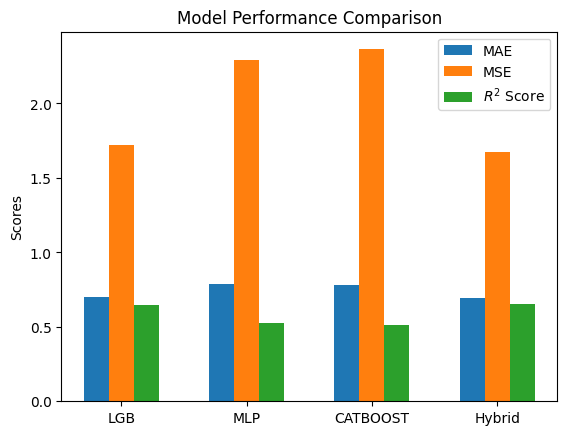

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and metrics
models = ['LGB', 'MLP', 'CATBOOST', 'Hybrid']
mae_scores = [0.703, 0.789, 0.778, 0.696]
mse_scores = [1.722, 2.290, 2.364, 1.674]
r2_scores = [0.646, 0.529, 0.514, 0.656]

# Create bar positions
x = np.arange(len(models))
width = 0.2  # Width of the bars

# Create the bar graph
fig, ax = plt.subplots()
rects1 = ax.bar(x - width, mae_scores, width, label='MAE')
rects2 = ax.bar(x, mse_scores, width, label='MSE')
rects3 = ax.bar(x + width, r2_scores, width, label=r'$R^2$ Score')

# Add labels, title, and legend
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Display the graph
plt.show()